In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Membuka Dataset

In [2]:
data = pd.read_csv("HistoricalDailyWeatherRecords.csv")

# Cek struktur data
print(data.head())
print(data.info())

         date    station daily_rainfall_total highest_30_min_rainfall  \
0  2009-01-01  Admiralty                   na                      na   
1  2009-01-02  Admiralty                   na                      na   
2  2009-01-03  Admiralty                   na                      na   
3  2009-01-04  Admiralty                   na                      na   
4  2009-01-05  Admiralty                   na                      na   

  highest_60_min_rainfall highest_120_min_rainfall mean_temperature  \
0                      na                       na               na   
1                      na                       na               na   
2                      na                       na               na   
3                      na                       na               na   
4                      na                       na               na   

  maximum_temperature minimum_temperature mean_wind_speed max_wind_speed  
0                  na                  na              na  

## Data Exploration

In [3]:
# Cek missing values
data.replace('na', np.nan, inplace=True) # Mengubah data dengan value 'na' menjadi null value yang bisa dibaca python
print(data.isnull().sum())

date                           0
station                        0
daily_rainfall_total         105
highest_30_min_rainfall     1755
highest_60_min_rainfall     1755
highest_120_min_rainfall    1755
mean_temperature             139
maximum_temperature          115
minimum_temperature          115
mean_wind_speed               96
max_wind_speed                97
dtype: int64


In [4]:
# Cek tipe data

print(data.dtypes)

date                        object
station                     object
daily_rainfall_total        object
highest_30_min_rainfall     object
highest_60_min_rainfall     object
highest_120_min_rainfall    object
mean_temperature            object
maximum_temperature         object
minimum_temperature         object
mean_wind_speed             object
max_wind_speed              object
dtype: object


In [5]:
# Karena datatype masih tidak cocok, maka diconvert sesuai yang tertulis di website

for col in data.columns:
    if col == 'date':
        data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d', errors='coerce')
    elif col == 'station':
        data['station'] = data['station'].astype(str)
    else:
        data[col] = pd.to_numeric(data[col], errors='coerce')

print(data.dtypes)

date                        datetime64[ns]
station                             object
daily_rainfall_total               float64
highest_30_min_rainfall            float64
highest_60_min_rainfall            float64
highest_120_min_rainfall           float64
mean_temperature                   float64
maximum_temperature                float64
minimum_temperature                float64
mean_wind_speed                    float64
max_wind_speed                     float64
dtype: object


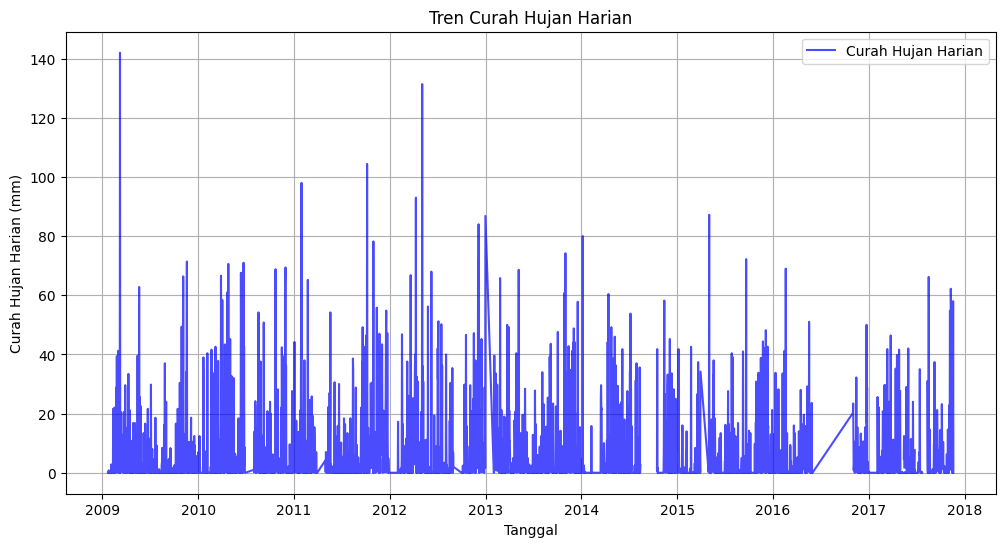

In [8]:
# Data Visualization

# Line plot untuk daily_rainfall_total terhadap waktu
plt.figure(figsize=(12, 6))
plt.plot(data['date'], data['daily_rainfall_total'], label='Curah Hujan Harian', color='blue', alpha=0.7)
plt.title('Tren Curah Hujan Harian')
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan Harian (mm)')
plt.legend()
plt.grid()
plt.show()